In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 2
mpl.rcParams['hatch.color'] = 'white'
#mpl.rcParams['hatch.spacing'] = 8.0

def findProjectRoot(startDir=None, marker="Input_Data"):
    current = os.path.abspath(startDir or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(current, marker)): return current
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError(f"No project root with '{marker}' above {os.getcwd()}")
        current = parent

projectRoot = findProjectRoot()
target      = "Ebola"
dataDir     = os.path.join(projectRoot, "Input_Data")
resultsDir  = os.path.join(projectRoot, target, f"Results_{target}")

Loaded /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/referenceDrugsDF_ARTprediction.csv, columns: ['Canonical_SMILES', 'drugName', 'pPotency_prediction', 'pPotency_std', 'pPotency_lower_95CI', 'pPotency_upper_95CI', 'IC50(M)_prediction', 'IC50(M)_lower_95CI', 'IC50(M)_upper_95CI']
Ebola observed values (n=12): [7.07, 6.85, 6.89, 7.22, 7.15, 7.18, 7.68, 7.85, 8.52, 7.11, 6.87, 7.15]
Ebola predicted pIC50 (mean +/- std): 6.629 +/- 0.470


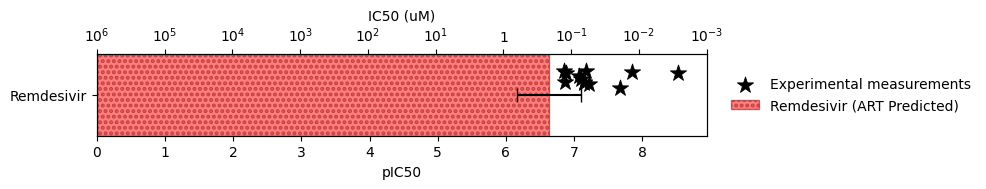

In [22]:
# Ebola(all) observed values, shown as individual points rather than a summary bar
ebola_all_vals = np.array([7.07, 6.85, 6.89, 7.22, 7.15, 7.18, 7.68, 7.85, 8.52, 7.11, 6.87, 7.15], dtype=float)

# Remdesivir predicted pPotency against Ebola, read from the ART reference-drug output
referenceDrugsPath = f'{resultsDir}/referenceDrugsDF_ARTprediction.csv'
referenceDrugsDf = pd.read_csv(referenceDrugsPath)
print(f"Loaded {referenceDrugsPath}, columns: {referenceDrugsDf.columns.tolist()}")

remdesivirRow = referenceDrugsDf[referenceDrugsDf['drugName'].str.strip().str.lower() == 'remdesivir']
if remdesivirRow.empty:
    raise ValueError("DECISION: no Remdesivir row found in referenceDrugsDF_ARTprediction.csv")
remdesivirRow = remdesivirRow.iloc[0]

rem_pred = remdesivirRow['pPotency_prediction']
rem_std  = remdesivirRow['pPotency_std']

def pic50ToIc50(pic50): return 10**(-pic50) * 1e6
def formatIc50(v):
    if v == 0: return '$0$'
    exp = int(np.floor(np.log10(abs(v))))
    man = v / (10**exp)
    if exp == 0: return f'${man:.2g}$'
    if abs(man - 1.0) < 0.01: return f'$10^{{{exp}}}$'
    return f'${man:.2f} \\times 10^{{{exp}}}$'

def jitterValues(count, spread=0.15, seed=7):
    rng = np.random.default_rng(seed)
    return rng.uniform(-spread, spread, size=count)

remdesivirY = 0
barHeight = 0.5

fig, axBottom = plt.subplots(figsize=(10, 2))

# Predicted bar: mean +/- std
axBottom.barh(remdesivirY, rem_pred, height=barHeight, xerr=rem_std, capsize=5,
              color='red', alpha=0.5, hatch='...', edgecolor='darkred', linewidth=1.0,
              label='Remdesivir (ART Predicted)')

# Experimental points: stars only, placed on top of the predicted bar
starY = remdesivirY + barHeight / 2 - 0.15
axBottom.scatter(ebola_all_vals, np.full(len(ebola_all_vals), starY) + jitterValues(len(ebola_all_vals), spread=0.06),
                  marker='*', s=150, color='black', edgecolor='black', linewidth=0.6, zorder=5,
                  label='Experimental measurements')

axBottom.set_yticks([remdesivirY])
axBottom.set_yticklabels(['Remdesivir'], fontsize=10)
#axBottom.set_ylim(remdesivirY - barHeight - 0.3, starY + 0.3)
axBottom.set_ylim(remdesivirY - barHeight / 2, remdesivirY + barHeight / 2)
axBottom.set_xlabel('pIC50', fontsize=10)
axBottom.tick_params(axis='both', labelsize=10)
axBottom.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=10)

# Secondary x-axis on top: IC50 (uM)
axTop = axBottom.twiny()
axTop.set_xlim(axBottom.get_xlim())
ticks = axBottom.get_xticks()
axTop.set_xticks(ticks)
axTop.set_xticklabels([formatIc50(pic50ToIc50(t)) for t in ticks], fontsize=10)
axTop.set_xlabel('IC50 (uM)', fontsize=10)
axTop.tick_params(axis='both', labelsize=10)

print(f"Ebola observed values (n={len(ebola_all_vals)}): {ebola_all_vals.tolist()}")
print(f"Ebola predicted pIC50 (mean +/- std): {rem_pred:.3f} +/- {rem_std:.3f}")

plt.tight_layout()
plt.savefig(resultsDir + '/experimental_comparison.png', dpi=1200, bbox_inches='tight')
plt.savefig(resultsDir + '/experimental_comparison.pdf', dpi=1200, bbox_inches='tight')
plt.show()

Loaded /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/referenceDrugsDF_ARTprediction.csv, columns: ['Canonical_SMILES', 'drugName', 'pPotency_prediction', 'pPotency_std', 'pPotency_lower_95CI', 'pPotency_upper_95CI', 'IC50(M)_prediction', 'IC50(M)_lower_95CI', 'IC50(M)_upper_95CI']
Found 66 bioactivity record(s) for Remdesivir in /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_potency_data.csv
Ebola observed values (n=12): [7.07, 6.85, 6.89, 7.22, 7.15, 7.18, 7.68, 7.85, 8.52, 7.11, 6.87, 7.15]
Ebola predicted pIC50 (mean +/- std): 6.629 +/- 0.470


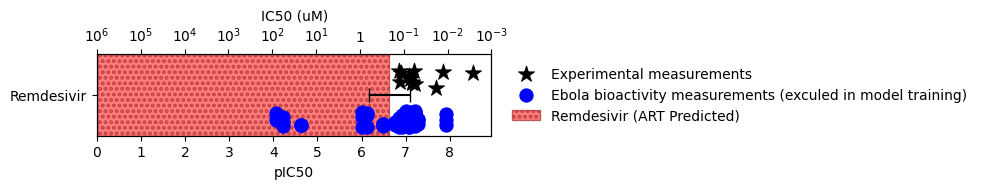

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from rdkit import Chem
mpl.rcParams['hatch.linewidth'] = 2
mpl.rcParams['hatch.color'] = 'white'
mpl.rcParams['font.size'] = 10
#mpl.rcParams['hatch.spacing'] = 8.0

def findProjectRoot(startDir=None, marker="Input_Data"):
    current = os.path.abspath(startDir or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(current, marker)): return current
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError(f"No project root with '{marker}' above {os.getcwd()}")
        current = parent

def canonicalizeSmiles(smilesString):
    molecule = Chem.MolFromSmiles(smilesString)
    if molecule is None:
        return None
    return Chem.MolToSmiles(molecule, canonical=True)

projectRoot = findProjectRoot()
target      = "Ebola"
dataDir     = os.path.join(projectRoot, "Input_Data")
resultsDir  = os.path.join(projectRoot, target, f"Results_{target}")

# Ebola(all) observed values, shown as individual points rather than a summary bar
ebola_all_vals = np.array([7.07, 6.85, 6.89, 7.22, 7.15, 7.18, 7.68, 7.85, 8.52, 7.11, 6.87, 7.15], dtype=float)

# Remdesivir predicted pPotency against Ebola, read from the ART reference-drug output
referenceDrugsPath = f'{resultsDir}/referenceDrugsDF_ARTprediction.csv'
referenceDrugsDf = pd.read_csv(referenceDrugsPath)
print(f"Loaded {referenceDrugsPath}, columns: {referenceDrugsDf.columns.tolist()}")

remdesivirRow = referenceDrugsDf[referenceDrugsDf['drugName'].str.strip().str.lower() == 'remdesivir']
if remdesivirRow.empty:
    raise ValueError("DECISION: no Remdesivir row found in referenceDrugsDF_ARTprediction.csv")
remdesivirRow = remdesivirRow.iloc[0]

rem_pred = remdesivirRow['pPotency_prediction']
rem_std  = remdesivirRow['pPotency_std']

# Bioactivity records for Remdesivir, matched by canonical SMILES rather than by name,
# since compound_id in Ebola_potency_data.csv does not carry a drug name.
remdesivirSmiles = "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1"
remdesivirCanonicalSmiles = canonicalizeSmiles(remdesivirSmiles)

potencyDataPath = f'{resultsDir}/Ebola_potency_data.csv'
potencyDataDf = pd.read_csv(potencyDataPath)
potencyDataDf['canonicalSmiles'] = potencyDataDf['Canonical_SMILES'].apply(canonicalizeSmiles)

remdesivirBioactivityDf = potencyDataDf[potencyDataDf['canonicalSmiles'] == remdesivirCanonicalSmiles]
remdesivirBioactivityVals = remdesivirBioactivityDf['pPotency'].to_numpy(dtype=float)
print(f"Found {len(remdesivirBioactivityVals)} bioactivity record(s) for Remdesivir in {potencyDataPath}")

def pic50ToIc50(pic50): return 10**(-pic50) * 1e6
def formatIc50(v):
    if v == 0: return '$0$'
    exp = int(np.floor(np.log10(abs(v))))
    man = v / (10**exp)
    if exp == 0: return f'${man:.2g}$'
    if abs(man - 1.0) < 0.01: return f'$10^{{{exp}}}$'
    return f'${man:.2f} \\times 10^{{{exp}}}$'

def jitterValues(count, spread=0.15, seed=7):
    rng = np.random.default_rng(seed)
    return rng.uniform(-spread, spread, size=count)

remdesivirY = 0
barHeight = 0.5

fig, axBottom = plt.subplots(figsize=(10, 2))

# Predicted bar: mean +/- std
axBottom.barh(remdesivirY, rem_pred, height=barHeight, xerr=rem_std, capsize=5,
              color='red', alpha=0.5, hatch='...', edgecolor='darkred', linewidth=1.0,
              label='Remdesivir (ART Predicted)')

# Experimental points: stars only, placed on top of the predicted bar
starY = remdesivirY + barHeight / 2 - 0.15
axBottom.scatter(ebola_all_vals, np.full(len(ebola_all_vals), starY) + jitterValues(len(ebola_all_vals), spread=0.06),
                  marker='*', s=150, color='black', edgecolor='black', linewidth=0.6, zorder=5,
                  label='Experimental measurements')

# Ebola_potency_data.csv bioactivity records for Remdesivir, shown as green circles
if len(remdesivirBioactivityVals) > 0:
    circleY = remdesivirY - barHeight / 2 + 0.10
    axBottom.scatter(remdesivirBioactivityVals, np.full(len(remdesivirBioactivityVals), circleY) + jitterValues(len(remdesivirBioactivityVals), spread=0.05, seed=11),
                      marker='o', s=90, facecolor='b', edgecolor='b', linewidth=0.8, zorder=5,
                      label='Ebola bioactivity measurements (exculed in model training)')
else:
    print("TODO: no matching Remdesivir SMILES found in Ebola_potency_data.csv, skipping green circles")

axBottom.set_yticks([remdesivirY])
axBottom.set_yticklabels(['Remdesivir'], fontsize=10)
axBottom.set_ylim(remdesivirY - barHeight / 2, remdesivirY + barHeight / 2)
axBottom.set_xlabel('pIC50', fontsize=10)
axBottom.tick_params(axis='both', labelsize=10)
axBottom.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=10)

# Secondary x-axis on top: IC50 (uM)
axTop = axBottom.twiny()
axTop.set_xlim(axBottom.get_xlim())
ticks = axBottom.get_xticks()
axTop.set_xticks(ticks)
axTop.set_xticklabels([formatIc50(pic50ToIc50(t)) for t in ticks], fontsize=10)
axTop.set_xlabel('IC50 (uM)', fontsize=10)
axTop.tick_params(axis='both', labelsize=10)

print(f"Ebola observed values (n={len(ebola_all_vals)}): {ebola_all_vals.tolist()}")
print(f"Ebola predicted pIC50 (mean +/- std): {rem_pred:.3f} +/- {rem_std:.3f}")

plt.tight_layout()
plt.savefig(resultsDir + '/experimental_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(resultsDir + '/experimental_comparison.pdf', bbox_inches='tight')
plt.show()